# 🔬 EigenCAM vs GradCAM Visualization

**Pipeline Overview:**
1. Load YOLO model → Run inference on validation images
2. Generate **EigenCAM heatmaps**
3. Generate GradCAM Heatmaps
4. COmparison

In [1]:
!pip install ultralytics grad-cam google-generativeai pillow tqdm --quiet
print("✅ Dependencies installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.4 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.1 MB/s eta 0:00:00
✅ Dependencies installed


In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from ultralytics import YOLO
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import warnings
warnings.filterwarnings("ignore")

# Pastikan matplotlib render inline di notebook (bukan backend Agg).
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("✅ All imports successful")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ All imports successful
   GPU: Tesla T4


## ⚙️ Configuration
**⚠️ UPDATE THESE PATHS** to match your Kaggle environment before running!

In [3]:
# ============================================================
# 🔧 CONFIGURATION
# ============================================================
MODEL_PATH = "/kaggle/input/models/kaylarizaa/bestest-model/pytorch/default/1/best.pt"
DATA_YAML = "/kaggle/input/datasets/kaylarizaa/coda-dataset/dataset/data.yaml"
IMAGES_DIR = "/kaggle/input/datasets/kaylarizaa/coda-dataset/dataset/images/val"
LABELS_DIR = "/kaggle/input/datasets/kaylarizaa/coda-dataset/dataset/labels/val"
OUTPUT_DIR = "/kaggle/working/vlm_dataset"

CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.5
TARGET_LAYER_IDX = 21
MAX_OBJECTS_PER_IMAGE = 3

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "panels"), exist_ok=True)

for name, path in [("Model", MODEL_PATH), ("Data YAML", DATA_YAML), ("Images", IMAGES_DIR), ("Labels", LABELS_DIR)]:
    exists = os.path.exists(path)
    status = "✅" if exists else "❌ NOT FOUND"
    print(f"  {status} {name}: {path}")

print(f"\n  Output: {OUTPUT_DIR}")

  ✅ Model: /kaggle/input/models/kaylarizaa/bestest-model/pytorch/default/1/best.pt
  ✅ Data YAML: /kaggle/input/datasets/kaylarizaa/coda-dataset/dataset/data.yaml
  ✅ Images: /kaggle/input/datasets/kaylarizaa/coda-dataset/dataset/images/val
  ✅ Labels: /kaggle/input/datasets/kaylarizaa/coda-dataset/dataset/labels/val

  Output: /kaggle/working/vlm_dataset


## 🔧 Core Functions
YOLO wrapper, ground truth loading, IoU computation, and prediction matching.

In [4]:
class YOLOWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(x)[0]

print("✅ Core wrapper loaded")

✅ Core wrapper loaded


## 🔥 EigenCAM Heatmap Generator

In [5]:
def generate_eigencam(model_yolo, img_rgb, device, target_layer_idx=15):
    h_img, w_img = img_rgb.shape[:2]
    rgb_float = np.float32(img_rgb) / 255.0
    img_resized = cv2.resize(img_rgb, (640, 640))
    img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float().unsqueeze(0).to(device) / 255.0

    target_layers = [model_yolo.model.model[target_layer_idx]]
    cam = EigenCAM(model=YOLOWrapper(model_yolo.model), target_layers=target_layers)
    grayscale_cam = cv2.resize(cam(input_tensor=img_tensor)[0, :], (w_img, h_img))

    cam_max = np.max(grayscale_cam)
    if cam_max > 0: grayscale_cam = grayscale_cam / (cam_max + 1e-8)
    return grayscale_cam, show_cam_on_image(rgb_float, grayscale_cam, use_rgb=True)

print("✅ EigenCAM generator loaded")

✅ EigenCAM generator loaded


## 🔥 GradCAM Heatmap Generator

In [6]:
from pytorch_grad_cam import GradCAM

class YOLOBoxScoreTarget:
    """GradCAM target untuk model deteksi YOLO (pakai top-k skor objek)."""
    def __init__(self, topk=10):
        self.topk = topk

    def __call__(self, model_output):
        if isinstance(model_output, (tuple, list)):
            model_output = model_output[0]

        if model_output.ndim == 3 and model_output.shape[1] < model_output.shape[2]:
            pred = model_output.permute(0, 2, 1)
        elif model_output.ndim == 3:
            pred = model_output
        else:
            return model_output.reshape(-1).sum()

        if pred.shape[-1] >= 5:
            obj_conf = pred[..., 4]
            if pred.shape[-1] > 5:
                cls_conf = pred[..., 5:].amax(dim=-1)
                score = obj_conf * cls_conf
            else:
                score = obj_conf
        else:
            score = pred.amax(dim=-1)

        k = min(self.topk, score.shape[-1])
        topk_vals = torch.topk(score, k=k, dim=-1).values
        return topk_vals.sum()


def _collect_gradcam_layers(wrapped_model, target_layer_idx=None):
    layers = []
    detect_stack = getattr(wrapped_model, "model", None)
    detect_stack = getattr(detect_stack, "model", None)

    if isinstance(target_layer_idx, int) and detect_stack is not None and 0 <= target_layer_idx < len(detect_stack):
        layers.append(detect_stack[target_layer_idx])

    conv_layers = [m for m in wrapped_model.modules() if isinstance(m, torch.nn.Conv2d)]
    if conv_layers:
        layers.append(conv_layers[-1])
    if len(conv_layers) > 1:
        layers.append(conv_layers[-2])

    # Deduplicate while preserving order.
    uniq = []
    seen = set()
    for l in layers:
        lid = id(l)
        if lid not in seen:
            uniq.append(l)
            seen.add(lid)
    return uniq


def _normalize_cam(cam_map):
    cam_map = np.nan_to_num(cam_map, nan=0.0, posinf=0.0, neginf=0.0)
    cam_map = np.maximum(cam_map, 0)
    m = cam_map.max()
    if m > 0:
        cam_map = cam_map / (m + 1e-8)
    return cam_map


def generate_gradcam(model_yolo, img_rgb, device, target_layer_idx=15, topk=10):
    h_img, w_img = img_rgb.shape[:2]
    rgb_float = np.float32(img_rgb) / 255.0
    img_resized = cv2.resize(img_rgb, (640, 640))
    img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).unsqueeze(0).to(device).float() / 255.0
    img_tensor.requires_grad_(True)

    wrapped_model = YOLOWrapper(model_yolo.model).to(device).float()
    wrapped_model.eval()
    for p in wrapped_model.parameters():
        p.requires_grad_(True)

    targets = [YOLOBoxScoreTarget(topk=topk)]
    candidate_layers = _collect_gradcam_layers(wrapped_model, target_layer_idx)
    if not candidate_layers:
        raise RuntimeError("No candidate Conv2d layer found for GradCAM.")

    last_err = None
    for layer in candidate_layers:
        try:
            cam = GradCAM(model=wrapped_model, target_layers=[layer])
            with torch.enable_grad():
                grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]
            grayscale_cam = cv2.resize(grayscale_cam, (w_img, h_img))
            grayscale_cam = _normalize_cam(grayscale_cam)

            # Validasi CAM supaya tidak blank.
            if float(grayscale_cam.max()) <= 1e-6 or float(grayscale_cam.std()) <= 1e-6:
                continue

            overlay = show_cam_on_image(rgb_float, grayscale_cam, use_rgb=True)
            return grayscale_cam, overlay
        except Exception as e:
            last_err = e
            continue

    raise RuntimeError(f"GradCAM failed on all candidate layers: {last_err}")

print("✅ GradCAM generator loaded (validated YOLO-aware target)")

✅ GradCAM generator loaded (validated YOLO-aware target)


## 📊 EigenCAM vs GradCAM Comparison (Pyplot)

In [7]:
def plot_cam_comparison(img_rgb, eigencam_overlay, gradcam_overlay, title_suffix=""):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(img_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(eigencam_overlay)
    axes[1].set_title("EigenCAM")
    axes[1].axis("off")

    axes[2].imshow(gradcam_overlay)
    axes[2].set_title("GradCAM")
    axes[2].axis("off")

    if title_suffix:
        fig.suptitle(f"CAM Comparison - {title_suffix}", fontsize=14, fontweight="bold")
    else:
        fig.suptitle("CAM Comparison", fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()


def run_cam_comparison(model_yolo, image_path, device, target_layer_idx=15):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Image not found or unreadable: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    _, eigen_overlay = generate_eigencam(
        model_yolo=model_yolo,
        img_rgb=img_rgb,
        device=device,
        target_layer_idx=target_layer_idx,
    )

    _, grad_overlay = generate_gradcam(
        model_yolo=model_yolo,
        img_rgb=img_rgb,
        device=device,
        target_layer_idx=target_layer_idx,
    )

    plot_cam_comparison(
        img_rgb=img_rgb,
        eigencam_overlay=eigen_overlay,
        gradcam_overlay=grad_overlay,
        title_suffix=Path(image_path).name,
    )

print("✅ Comparison pyplot utilities loaded")

✅ Comparison pyplot utilities loaded


## 🚀 Inference Runner: EigenCAM vs GradCAM

Using device: cuda
Loading YOLO model...
✅ YOLO model loaded
Total images found: 977
Using single sample: 0004.jpg
EigenCAM stats -> min: 0.0000, max: 1.0000, std: 0.1565
GradCAM  stats -> min: 0.0000, max: 1.0000, std: 0.2513


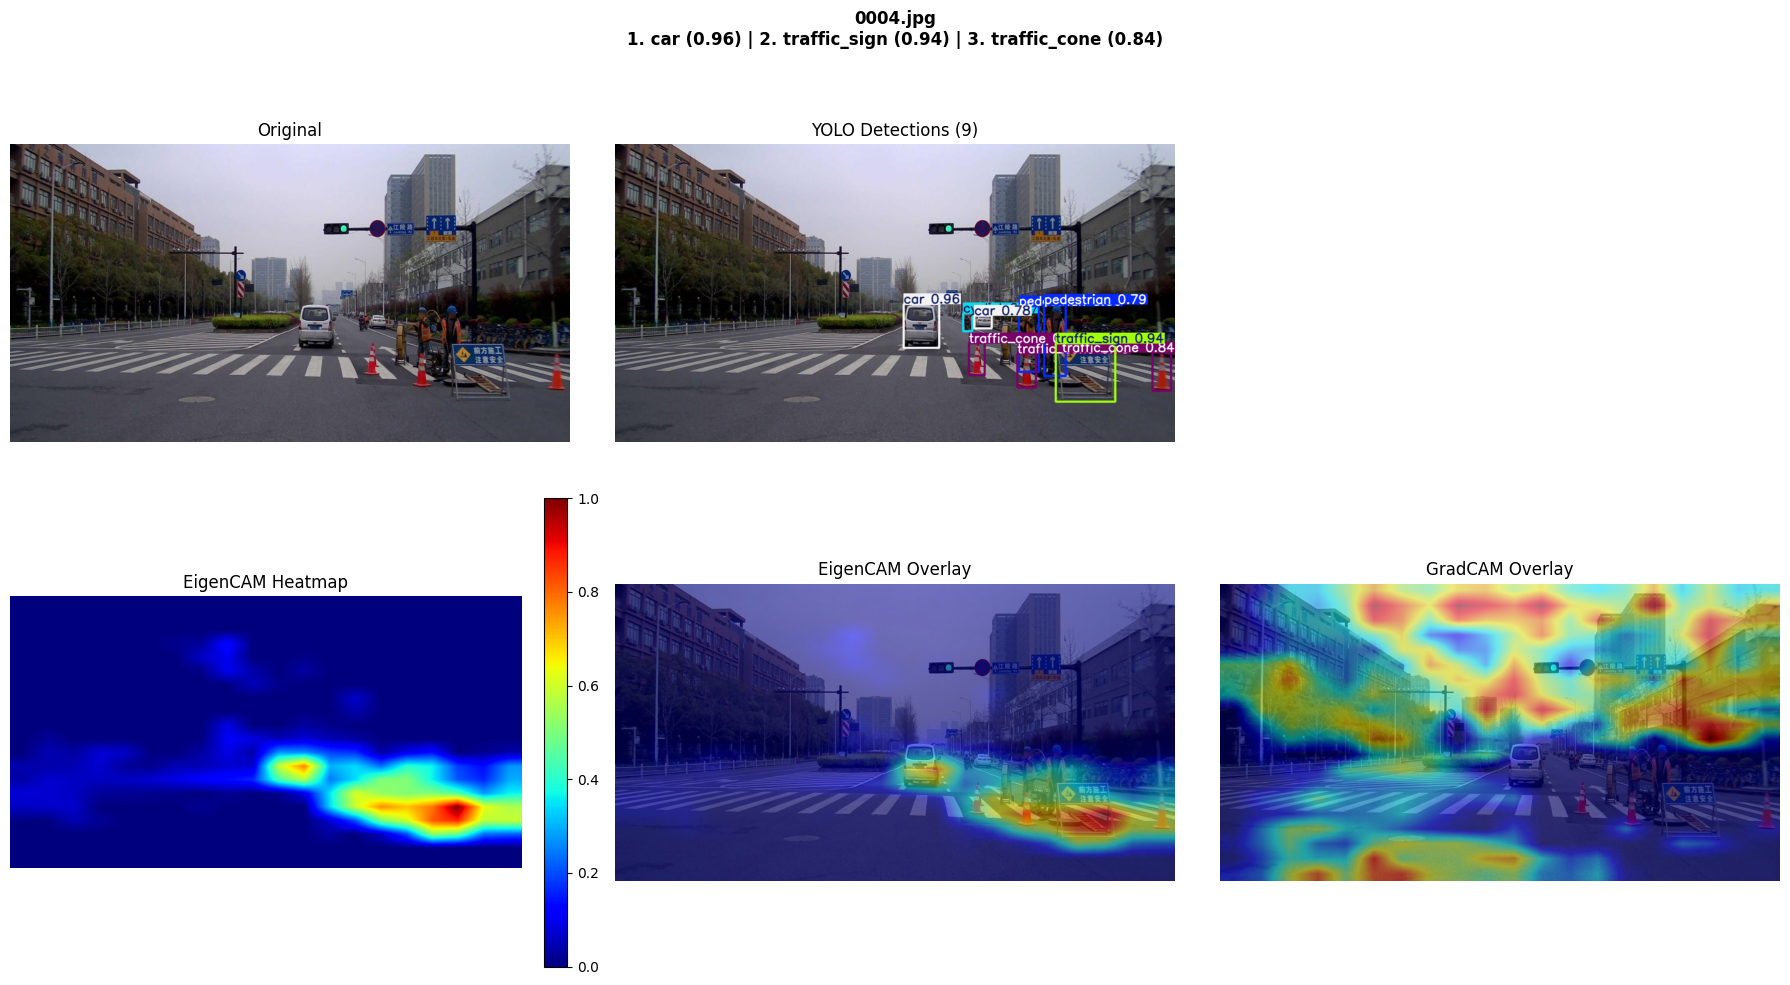

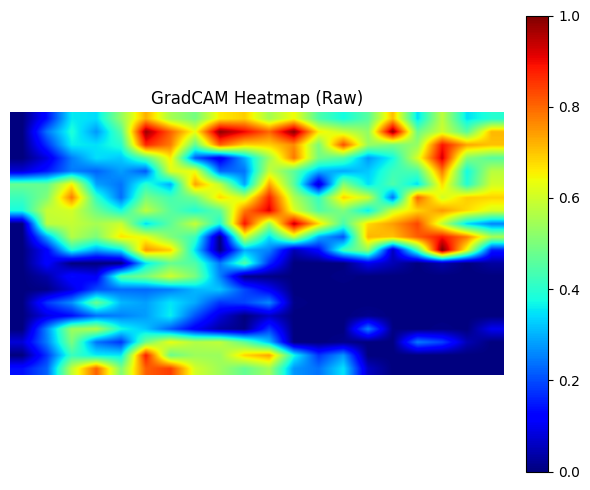


✅ Single-sample CAM comparison finished
Detections: 9
GradCAM std: 0.251313


In [8]:
# ============================================
# Inference + CAM Comparison Runner (Single Sample, Matplotlib Only)
# ============================================
device = "cuda" if torch.cuda.is_available() else "cpu"
device_for_yolo = 0 if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")
print("Loading YOLO model...")
model_yolo = YOLO(MODEL_PATH)
print("✅ YOLO model loaded")

valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths = sorted([
    str(p) for p in Path(IMAGES_DIR).glob("*") if p.suffix.lower() in valid_exts
])

if not image_paths:
    raise FileNotFoundError(f"No images found in IMAGES_DIR: {IMAGES_DIR}")

selected_image = image_paths[0]
print(f"Total images found: {len(image_paths)}")
print(f"Using single sample: {Path(selected_image).name}")

def _render_cam_comparison_with_detections(
    image_path,
    model_yolo,
    device,
    target_layer_idx=15,
    conf_thres=0.25,
    iou_thres=0.5,
    max_objects_per_image=3,
 ):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Image not found or unreadable: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    results = model_yolo.predict(
        source=image_path,
        conf=conf_thres,
        iou=iou_thres,
        device=device_for_yolo,
        verbose=False,
    )
    result = results[0]
    det_overlay = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)

    det_count = 0
    class_lines = []
    if result.boxes is not None and len(result.boxes) > 0:
        det_count = len(result.boxes)
        for idx in range(min(det_count, max_objects_per_image)):
            cls_id = int(result.boxes.cls[idx].item())
            conf = float(result.boxes.conf[idx].item())
            cls_name = model_yolo.names.get(cls_id, str(cls_id))
            class_lines.append(f"{idx+1}. {cls_name} ({conf:.2f})")

    eigen_cam, eigen_overlay = generate_eigencam(
        model_yolo=model_yolo,
        img_rgb=img_rgb,
        device=device,
        target_layer_idx=target_layer_idx,
    )
    grad_cam, grad_overlay = generate_gradcam(
        model_yolo=model_yolo,
        img_rgb=img_rgb,
        device=device,
        target_layer_idx=target_layer_idx,
        topk=30,
    )

    print(f"EigenCAM stats -> min: {eigen_cam.min():.4f}, max: {eigen_cam.max():.4f}, std: {eigen_cam.std():.4f}")
    print(f"GradCAM  stats -> min: {grad_cam.min():.4f}, max: {grad_cam.max():.4f}, std: {grad_cam.std():.4f}")

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title("Original")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(det_overlay)
    axes[0, 1].set_title(f"YOLO Detections ({det_count})")
    axes[0, 1].axis("off")

    axes[0, 2].axis("off")

    im1 = axes[1, 0].imshow(eigen_cam, cmap="jet")
    axes[1, 0].set_title("EigenCAM Heatmap")
    axes[1, 0].axis("off")
    plt.colorbar(im1, ax=axes[1, 0], fraction=0.046, pad=0.04)

    axes[1, 1].imshow(eigen_overlay)
    axes[1, 1].set_title("EigenCAM Overlay")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(grad_overlay)
    axes[1, 2].set_title("GradCAM Overlay")
    axes[1, 2].axis("off")

    fname = Path(image_path).name
    subtitle = " | ".join(class_lines) if class_lines else "No detections"
    fig.suptitle(f"{fname}\n{subtitle}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Tambahan visual murni heatmap GradCAM agar jelas tidak blank.
    plt.figure(figsize=(6, 5))
    im2 = plt.imshow(grad_cam, cmap="jet")
    plt.title("GradCAM Heatmap (Raw)")
    plt.axis("off")
    plt.colorbar(im2, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    return {
        "image": image_path,
        "detections": det_count,
        "gradcam_std": float(grad_cam.std()),
    }

try:
    report = _render_cam_comparison_with_detections(
        image_path=selected_image,
        model_yolo=model_yolo,
        device=device,
        target_layer_idx=TARGET_LAYER_IDX,
        conf_thres=CONF_THRESHOLD,
        iou_thres=IOU_THRESHOLD,
        max_objects_per_image=MAX_OBJECTS_PER_IMAGE,
    )
    print("\n✅ Single-sample CAM comparison finished")
    print(f"Detections: {report['detections']}")
    print(f"GradCAM std: {report['gradcam_std']:.6f}")
except Exception as e:
    print(f"⚠️ Failed on sample {Path(selected_image).name}: {e}")